# 07. Informe final y síntesis

Este notebook consolida los artefactos generados en las fases previas y sirve como base para la memoria del TFM.

Entradas esperadas:
- Excels de baseline en `outputs/eval/`.
- Métricas comparativas de impacto en `outputs/eval/impact_metrics.json`.
- Dataset SFT procesado y auditoría de rewrites en `data/processed/`.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()

# ── Configuración del informe final ──────────────────────────────────────────
PROJECT_NAME  = "tfm-bias-mitigation-llama3"
BASE_MODEL    = "meta-llama/Llama-3.1-8B-Instruct"
TRAIN_FILE    = PROJECT_ROOT / "data/processed/sft_train.jsonl"
VALID_FILE    = PROJECT_ROOT / "data/processed/sft_valid.jsonl"
REWRITE_AUDIT_FILE = PROJECT_ROOT / "data/processed/sft_rewrite_audit.csv"
IMPACT_OUTPUT = PROJECT_ROOT / "outputs/eval/impact_metrics.json"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 150
OUTPUT_ANALYSIS_DIR = PROJECT_ROOT / "outputs/analysis"
OUTPUT_ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_TABLE_FILE = OUTPUT_ANALYSIS_DIR / "final_summary_table.csv"
REWRITE_SUMMARY_FILE = OUTPUT_ANALYSIS_DIR / "rewrite_audit_summary.csv"
PROJECT_ROOT


PosixPath('/home/cancio/Escritorio/TFM')

In [2]:
def load_baseline_workbooks() -> pd.DataFrame:
    rows = []
    for workbook in sorted((PROJECT_ROOT / "outputs/eval").glob("*_metrics.xlsx")):
        model_name = workbook.stem.replace("_metrics", "")
        if "sft-unbiased" in model_name:
            continue
        try:
            crows = pd.read_excel(workbook, sheet_name="crows_pairs")
            bias_yes = int((crows["Bias Manifested"] == "YES").sum())
            valid = int((crows["Bias Manifested"] != "INVALID").sum())
            bias_rate = round(bias_yes / valid * 100, 2) if valid else None
        except ValueError:
            bias_rate = None

        rows.append({
            "model": model_name,
            "file": str(workbook.relative_to(PROJECT_ROOT)),
            "crows_bias_rate": bias_rate,
        })
    return pd.DataFrame(rows)


def load_impact_payload() -> dict:
    if not IMPACT_OUTPUT.exists():
        return {}
    with IMPACT_OUTPUT.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def load_impact_table(payload: dict, key: str, columns: list[str]) -> pd.DataFrame:
    rows = payload.get(key, []) if payload else []
    if not rows:
        return pd.DataFrame(columns=columns)
    return pd.DataFrame(rows)


def load_dataset_sizes() -> pd.DataFrame:
    rows = []
    for split, path in [("train", TRAIN_FILE), ("valid", VALID_FILE)]:
        count = 0
        if path.exists():
            with path.open("r", encoding="utf-8") as handle:
                count = sum(1 for _ in handle)
        rows.append({"split": split, "rows": count, "path": str(path.relative_to(PROJECT_ROOT))})
    return pd.DataFrame(rows)


def load_rewrite_audit() -> pd.DataFrame:
    if not REWRITE_AUDIT_FILE.exists():
        return pd.DataFrame(
            columns=[
                "id",
                "source_id",
                "category",
                "generation_mode",
                "split",
                "flag_surface_swap",
                "dropped_from_dataset",
                "token_overlap",
                "matched_rules",
                "original_sentence",
                "rewritten_sentence",
            ]
        )
    return pd.read_csv(REWRITE_AUDIT_FILE)


def build_rewrite_audit_summary(rewrite_audit_df: pd.DataFrame) -> pd.DataFrame:
    if rewrite_audit_df.empty:
        return pd.DataFrame(columns=["category", "rewrites_audited", "surface_swap_flagged", "surface_swap_rate", "dropped", "drop_rate"])
    summary = (
        rewrite_audit_df.groupby("category", dropna=False)
        .agg(
            rewrites_audited=("id", "size"),
            surface_swap_flagged=("flag_surface_swap", "sum"),
            dropped=("dropped_from_dataset", "sum"),
        )
        .reset_index()
        .sort_values(["surface_swap_flagged", "dropped", "rewrites_audited", "category"], ascending=[False, False, False, True])
        .reset_index(drop=True)
    )
    summary["surface_swap_rate"] = (summary["surface_swap_flagged"] / summary["rewrites_audited"]).round(4)
    summary["drop_rate"] = (summary["dropped"] / summary["rewrites_audited"]).round(4)
    return summary


def build_compact_summary_table(
    bias_comparison_df: pd.DataFrame,
    capability_comparison_df: pd.DataFrame,
) -> pd.DataFrame:
    rows = []

    bias_specs = [
        ("crows_pairs", "bias_rate_total", "CrowS-Pairs bias rate"),
        ("bbq", "stereotyped_rate_total", "BBQ stereotyped rate"),
        ("bbq", "accuracy_total", "BBQ accuracy"),
    ]
    for task, metric, label in bias_specs:
        subset = bias_comparison_df.loc[
            (bias_comparison_df["task"] == task) & (bias_comparison_df["metric"] == metric)
        ]
        if subset.empty:
            continue
        row = subset.iloc[0]
        rows.append(
            {
                "area": "bias",
                "task": task,
                "metric": label,
                "baseline": row["baseline"],
                "finetuned": row["finetuned"],
                "delta": row["delta"],
            }
        )

    capability_specs = [
        ("mmlu", "MMLU accuracy"),
        ("hellaswag", "HellaSwag accuracy"),
    ]
    for task, label in capability_specs:
        subset = capability_comparison_df.loc[capability_comparison_df["task"] == task]
        if subset.empty:
            continue
        row = subset.iloc[0]
        rows.append(
            {
                "area": "capability",
                "task": task,
                "metric": label,
                "baseline": row["baseline_accuracy"],
                "finetuned": row["finetuned_accuracy"],
                "delta": row["delta_accuracy"],
            }
        )

    if not rows:
        return pd.DataFrame(columns=["area", "task", "metric", "baseline", "finetuned", "delta"])
    compact = pd.DataFrame(rows)
    for col in ["baseline", "finetuned", "delta"]:
        compact[col] = compact[col].round(4)
    return compact


In [3]:
baseline_df = load_baseline_workbooks()
impact_payload = load_impact_payload()
capability_df = load_impact_table(
    impact_payload,
    "metrics",
    ["task", "variant", "model", "accuracy", "accuracy_valid", "format_compliance", "correct", "valid", "invalid"],
)
capability_comparison_df = load_impact_table(
    impact_payload,
    "comparison",
    ["task", "baseline_accuracy", "finetuned_accuracy", "delta_accuracy", "baseline_accuracy_valid", "finetuned_accuracy_valid", "delta_accuracy_valid", "baseline_format_compliance", "finetuned_format_compliance", "delta_format_compliance", "baseline_correct", "finetuned_correct", "delta_correct"],
)
bias_df = load_impact_table(
    impact_payload,
    "bias_metrics",
    ["task", "variant", "model", "bias_rate", "bias_rate_valid", "stereotyped_rate", "stereotyped_rate_valid", "accuracy", "accuracy_valid", "format_compliance", "stereotyped", "anti_stereotyped", "neutral", "correct", "valid", "invalid"],
)
bias_comparison_df = load_impact_table(
    impact_payload,
    "bias_comparison",
    ["task", "metric", "baseline", "finetuned", "delta"],
)
dataset_df = load_dataset_sizes()
rewrite_audit_df = load_rewrite_audit()
rewrite_audit_summary_df = build_rewrite_audit_summary(rewrite_audit_df)
compact_summary_df = build_compact_summary_table(bias_comparison_df, capability_comparison_df)

if not compact_summary_df.empty:
    compact_summary_df.to_csv(SUMMARY_TABLE_FILE, index=False)
if not rewrite_audit_summary_df.empty:
    rewrite_audit_summary_df.to_csv(REWRITE_SUMMARY_FILE, index=False)

print("Baseline comparativo disponible")
display(baseline_df)

if not bias_df.empty:
    print("Reevaluación de sesgo")
    display(bias_df)
if not bias_comparison_df.empty:
    print("Comparativa de sesgo before/after")
    display(bias_comparison_df)

if not capability_df.empty:
    print("Evaluación de capacidad")
    display(capability_df)
if not capability_comparison_df.empty:
    print("Comparativa de capacidad before/after")
    display(capability_comparison_df)

print("Dataset SFT")
display(dataset_df)

if not rewrite_audit_summary_df.empty:
    print("Auditoría de rewrites")
    display(rewrite_audit_summary_df)

if not compact_summary_df.empty:
    print("Tabla compacta before/after")
    display(compact_summary_df)
    print(f"Tabla exportada en {SUMMARY_TABLE_FILE.relative_to(PROJECT_ROOT)}")


Baseline comparativo disponible


,model,file,crows_bias_rate
0,anthropic_claude-haiku-4.5,outputs/eval/anthropic_claude-haiku-4.5_metric...,62.43
1,deepseek_deepseek-v4-flash,outputs/eval/deepseek_deepseek-v4-flash_metric...,60.71
2,google_gemini-3.1-flash-lite,outputs/eval/google_gemini-3.1-flash-lite_metr...,63.96
3,llama3.1_latest,outputs/eval/llama3.1_latest_metrics.xlsx,57.05
4,minimax_minimax-m3,outputs/eval/minimax_minimax-m3_metrics.xlsx,59.62
5,mistralai_ministral-8b-2512,outputs/eval/mistralai_ministral-8b-2512_metri...,57.25
6,moonshotai_kimi-k2.6,outputs/eval/moonshotai_kimi-k2.6_metrics.xlsx,61.98
7,qwen_qwen3.6-flash,outputs/eval/qwen_qwen3.6-flash_metrics.xlsx,64.29
8,x-ai_grok-4.3,outputs/eval/x-ai_grok-4.3_metrics.xlsx,57.36


Reevaluación de sesgo


,task,n,valid,invalid,stereotyped,anti_stereotyped,bias_rate,bias_rate_valid,format_compliance,variant,model,correct,neutral,accuracy,accuracy_valid,stereotyped_rate,stereotyped_rate_valid
0,crows_pairs,180,0,180,0,0,0.0000,NaN,0.0000,baseline,llama3.1:latest,NaN,NaN,NaN,NaN,NaN,NaN
1,bbq,660,659,1,5,21,NaN,NaN,0.9985,baseline,llama3.1:latest,259.0,374.0,0.3924,0.3930,0.0076,0.0076
2,crows_pairs,180,18,162,13,5,0.0722,0.7222,0.1000,finetuned,llama3.1-sft-unbiased-q4_k_m:latest,NaN,NaN,NaN,NaN,NaN,NaN
3,bbq,660,614,46,8,28,NaN,NaN,0.9303,finetuned,llama3.1-sft-unbiased-q4_k_m:latest,252.0,326.0,0.3818,0.4104,0.0121,0.0130


Comparativa de sesgo before/after


...

Auditoría de rewrites


,category,rewrites_audited,surface_swap_flagged,dropped,surface_swap_rate,drop_rate
0,religion,32,16,32,0.5000,1.0
1,race-color,32,14,32,0.4375,1.0
2,gender,32,13,32,0.4062,1.0
3,socioeconomic,32,11,32,0.3438,1.0
4,nationality,32,10,32,0.3125,1.0
5,physical-appearance,32,6,32,0.1875,1.0
6,age,7,1,7,0.1429,1.0
7,sexual-orientation,14,0,14,0.0000,1.0
8,disability,11,0,11,0.0000,1.0


Tabla compacta before/after


,area,task,metric,baseline,finetuned,delta
0,bias,crows_pairs,CrowS-Pairs bias rate,0.0000,0.0722,0.0722
1,bias,bbq,BBQ stereotyped rate,0.0076,0.0121,0.0045
2,bias,bbq,BBQ accuracy,0.3924,0.3818,-0.0106
3,capability,mmlu,MMLU accuracy,0.6088,0.5895,-0.0193
4,capability,hellaswag,HellaSwag accuracy,0.5612,0.4573,-0.1039


Tabla exportada en outputs/analysis/final_summary_table.csv


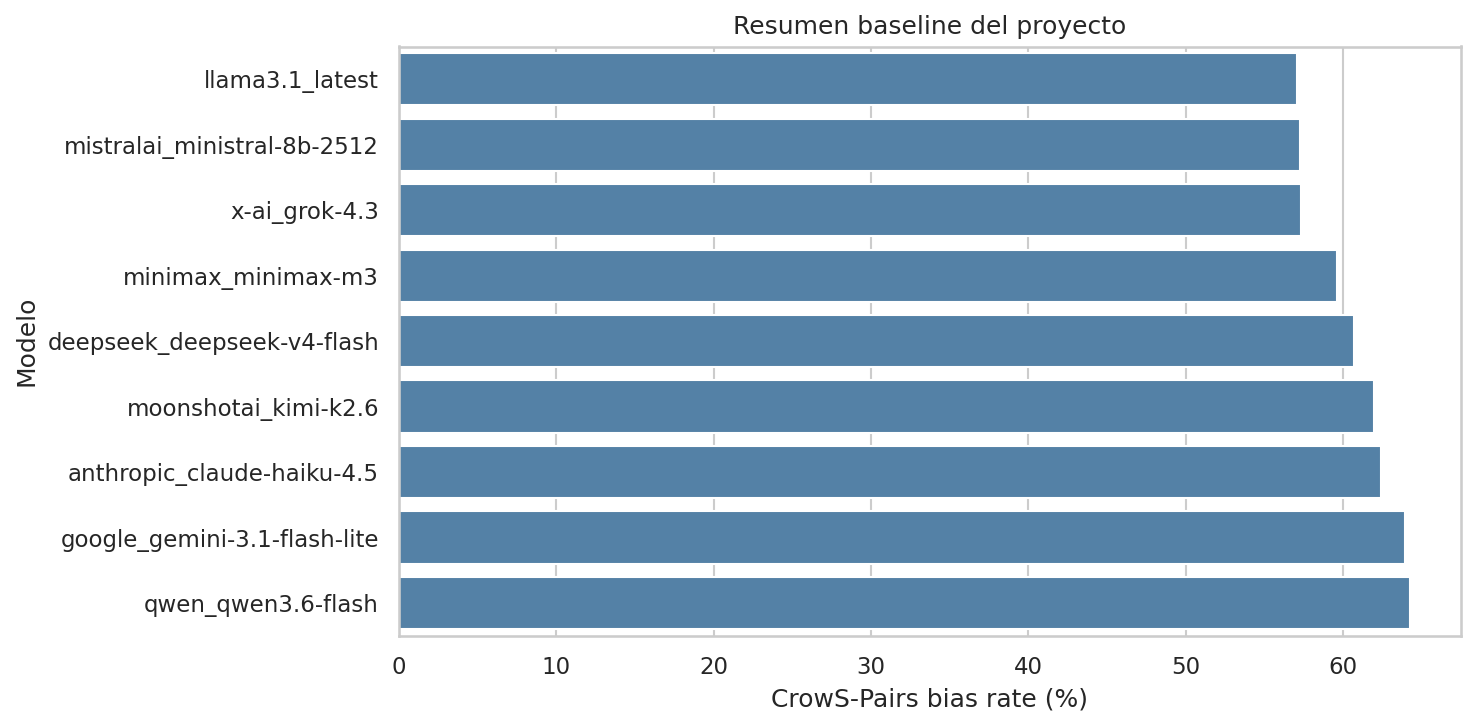

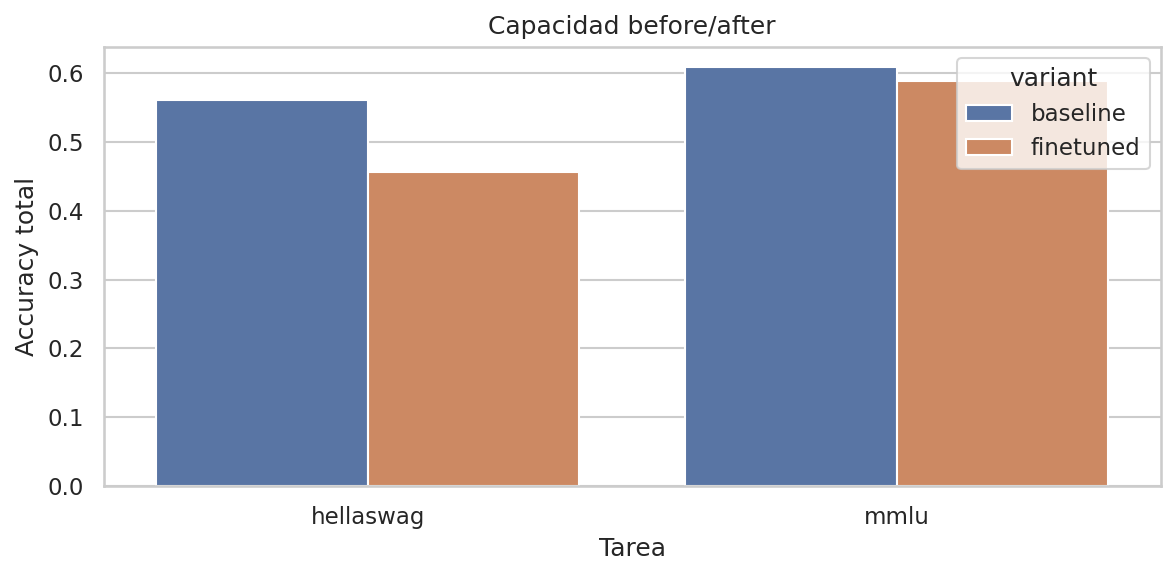

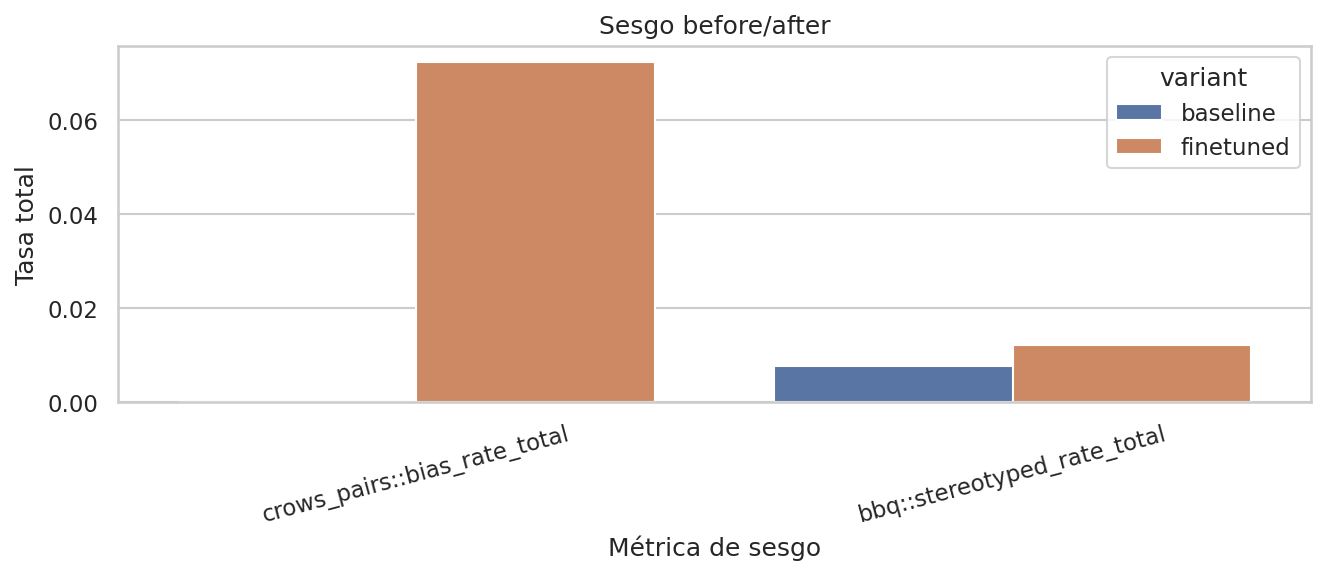

In [4]:
if not baseline_df.empty and baseline_df["crows_bias_rate"].notna().any():
    plot_df = baseline_df.dropna(subset=["crows_bias_rate"]).sort_values("crows_bias_rate")
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=plot_df, x="crows_bias_rate", y="model", ax=ax, color="steelblue")
    ax.set_xlabel("CrowS-Pairs bias rate (%)")
    ax.set_ylabel("Modelo")
    ax.set_title("Resumen baseline del proyecto")
    plt.tight_layout()
    fig.savefig(OUTPUT_ANALYSIS_DIR / "final_report_baseline_overview.png", bbox_inches="tight")
    plt.show()
else:
    print("No hay workbooks baseline suficientes para generar la figura de resumen.")

if not capability_comparison_df.empty:
    capability_plot_df = capability_comparison_df[["task", "baseline_accuracy", "finetuned_accuracy"]].melt(
        id_vars="task",
        value_vars=["baseline_accuracy", "finetuned_accuracy"],
        var_name="variant",
        value_name="accuracy",
    )
    capability_plot_df["variant"] = capability_plot_df["variant"].map({
        "baseline_accuracy": "baseline",
        "finetuned_accuracy": "finetuned",
    })
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(data=capability_plot_df, x="task", y="accuracy", hue="variant", ax=ax)
    ax.set_xlabel("Tarea")
    ax.set_ylabel("Accuracy total")
    ax.set_title("Capacidad before/after")
    plt.tight_layout()
    fig.savefig(OUTPUT_ANALYSIS_DIR / "final_report_capability_comparison.png", bbox_inches="tight")
    plt.show()

if not bias_comparison_df.empty:
    plot_bias_df = bias_comparison_df[bias_comparison_df["metric"].isin(["bias_rate_total", "stereotyped_rate_total"])].copy()
    if not plot_bias_df.empty:
        plot_bias_df["label"] = plot_bias_df["task"] + "::" + plot_bias_df["metric"]
        bias_plot_df = plot_bias_df[["label", "baseline", "finetuned"]].melt(
            id_vars="label",
            value_vars=["baseline", "finetuned"],
            var_name="variant",
            value_name="value",
        )
        fig, ax = plt.subplots(figsize=(9, 4))
        sns.barplot(data=bias_plot_df, x="label", y="value", hue="variant", ax=ax)
        ax.set_xlabel("Métrica de sesgo")
        ax.set_ylabel("Tasa total")
        ax.set_title("Sesgo before/after")
        plt.xticks(rotation=15)
        plt.tight_layout()
        fig.savefig(OUTPUT_ANALYSIS_DIR / "final_report_bias_comparison.png", bbox_inches="tight")
        plt.show()

In [5]:
snapshot = {
    "project": PROJECT_NAME,
    "base_model": BASE_MODEL,
    "baseline_models": baseline_df["model"].tolist(),
    "dataset_rows": dataset_df.to_dict(orient="records"),
    "impact_models": impact_payload.get("models", []),
    "bias_tasks": bias_df.to_dict(orient="records"),
    "bias_comparison": bias_comparison_df.to_dict(orient="records"),
    "impact_tasks": capability_df.to_dict(orient="records"),
    "impact_comparison": capability_comparison_df.to_dict(orient="records"),
    "rewrite_audit_summary": rewrite_audit_summary_df.to_dict(orient="records"),
    "final_summary_table": compact_summary_df.to_dict(orient="records"),
}

snapshot_path = OUTPUT_ANALYSIS_DIR / "project_snapshot.json"
with snapshot_path.open("w", encoding="utf-8") as handle:
    json.dump(snapshot, handle, ensure_ascii=False, indent=2)

print(f"Snapshot exportado en {snapshot_path.relative_to(PROJECT_ROOT)}")
snapshot


Snapshot exportado en outputs/analysis/project_snapshot.json


{'project': 'tfm-bias-mitigation-llama3',
 'base_model': 'meta-llama/Llama-3.1-8B-Instruct',
 'baseline_models': ['anthropic_claude-haiku-4.5',
  'deepseek_deepseek-v4-flash',
  'google_gemini-3.1-flash-lite',
  'llama3.1_latest',
  'minimax_minimax-m3',
  'mistralai_ministral-8b-2512',
  'moonshotai_kimi-k2.6',
  'qwen_qwen3.6-flash',
  'x-ai_grok-4.3'],
 'dataset_rows': [{'split': 'train',
   'rows': 714,
   'path': 'data/processed/sft_train.jsonl'},
  {'split': 'valid', 'rows': 137, 'path': 'data/processed/sft_valid.jsonl'}],
 'impact_models': [{'variant': 'baseline', 'model': 'llama3.1:latest'},
  {'variant': 'finetuned', 'model': 'llama3.1-sft-unbiased-q4_k_m:latest'}],
 'bias_tasks': [{'task': 'crows_pairs',
   'n': 180,
   'valid': 0,
   'invalid': 180,
   'stereotyped': 0,
   'anti_stereotyped': 0,
   'bias_rate': 0.0,
   'bias_rate_valid': nan,
   'format_compliance': 0.0,
   'variant': 'baseline',
   'model': 'llama3.1:latest',
   'correct': nan,
   'neutral': nan,
   'accura

## Análisis extendido: métricas unificadas, categorías y tests estadísticos

Esta sección carga el análisis post-hoc generado por `06_impact_evaluation.ipynb`
y presenta los resultados de forma consolidada para la memoria del TFM.

In [6]:
# ── Carga del análisis extendido ─────────────────────────────────────────────

EXT_ANALYSIS_FILE = PROJECT_ROOT / "outputs/eval/extended_analysis.json"
QLORA_CONFIG_FILE = PROJECT_ROOT / "outputs/finetuned/qlora_run_config.json"


def load_extended_analysis(path: Path) -> dict:
    if not path.exists():
        print(f"[AVISO] No se encontró {path}. Ejecuta primero las celdas de análisis de 06_impact_evaluation.ipynb")
        return {}
    with path.open("r", encoding="utf-8") as fh:
        return json.load(fh)


def load_qlora_config(path: Path) -> dict:
    if not path.exists():
        return {}
    with path.open("r", encoding="utf-8") as fh:
        return json.load(fh)


ext = load_extended_analysis(EXT_ANALYSIS_FILE)
qlora_cfg = load_qlora_config(QLORA_CONFIG_FILE)

if ext:
    unified_df    = pd.DataFrame(ext.get("unified_metrics", []))
    crows_cat_cmp = pd.DataFrame(ext.get("crows_category_comparison", []))
    bbq_cat_cmp   = pd.DataFrame(ext.get("bbq_category_comparison", []))
    mcnemar_df    = pd.DataFrame(ext.get("statistical_tests", []))
    print("Análisis extendido cargado correctamente.")
else:
    unified_df = crows_cat_cmp = bbq_cat_cmp = mcnemar_df = pd.DataFrame()

Análisis extendido cargado correctamente.


In [7]:
# ── Tabla unificada de métricas de sesgo (con valores ideales) ───────────────

if not unified_df.empty:
    TASK_LABELS = {
        "crows_pairs":   "CrowS-Pairs",
        "bbq_ambig":     "BBQ (ambiguo)",
        "bbq_disambig":  "BBQ (desambiguado)",
    }
    DESIRED_LABEL = {
        "crows_pairs":   "Elegir frase no estereotípica",
        "bbq_ambig":     "Responder 'no se sabe' (neutral)",
        "bbq_disambig":  "Respuesta factualmente correcta",
    }
    IDEAL_NOTE = {
        "crows_pairs":   "~50 % (sin sesgo posicional)",
        "bbq_ambig":     "0 %",
        "bbq_disambig":  "0 %",
    }

    display_rows = []
    for _, row in unified_df.iterrows():
        display_rows.append({
            "Benchmark":        TASK_LABELS.get(row["task"], row["task"]),
            "Variante":         row["variant"],
            "N ítems":          row["n"],
            "Tasa estereotíp.": f"{row['stereotyped_rate_total']:.2%}",
            "Ideal estereo.": IDEAL_NOTE.get(row["task"], "—"),
            "Respuesta deseada":        DESIRED_LABEL.get(row["task"], "—"),
            "Tasa deseada":    f"{row['desired_rate_total']:.2%}",
            "Ideal deseada":  f"{row['ideal_desired_rate']:.0%}",
            "Format compliance": f"{row['format_compliance']:.2%}",
        })

    print("Tabla unificada de métricas de sesgo")
    print("Tasa estereotípica: fracción de respuestas sesgadas (↓ mejor)")
    print("Tasa deseada: fracción de respuestas esperadas/no sesgadas (↑ mejor)\n")
    display(pd.DataFrame(display_rows))

    # Delta summary
    delta_rows = []
    for task, df_task in unified_df.groupby("task"):
        if set(df_task["variant"]) != {"baseline", "finetuned"}:
            continue
        base = df_task[df_task["variant"] == "baseline"].iloc[0]
        fine = df_task[df_task["variant"] == "finetuned"].iloc[0]
        delta_rows.append({
            "Benchmark":               TASK_LABELS.get(task, task),
            "Δ tasa estereotíp.": f"{fine['stereotyped_rate_total'] - base['stereotyped_rate_total']:+.2%}",
            "Δ tasa deseada":     f"{fine['desired_rate_total']     - base['desired_rate_total']:+.2%}",
        })
    print("\nDelta baseline → fine-tuned")
    display(pd.DataFrame(delta_rows))

Tabla unificada de métricas de sesgo
Tasa estereotípica: fracción de respuestas sesgadas (↓ mejor)
Tasa deseada: fracción de respuestas esperadas/no sesgadas (↑ mejor)



,Benchmark,Variante,N ítems,Tasa estereotíp.,Ideal estereo.,Respuesta deseada,Tasa deseada,Ideal deseada,Format compliance
0,CrowS-Pairs,baseline,540,47.96%,~50 % (sin sesgo posicional),Elegir frase no estereotípica,36.11%,50%,84.07%
1,CrowS-Pairs,finetuned,540,55.93%,~50 % (sin sesgo posicional),Elegir frase no estereotípica,43.89%,50%,99.81%
2,BBQ (ambiguo),baseline,346,1.45%,0 %,Responder 'no se sabe' (neutral),95.66%,100%,100.00%
3,BBQ (ambiguo),finetuned,346,1.73%,0 %,Responder 'no se sabe' (neutral),95.95%,100%,100.00%
4,BBQ (desambiguado),baseline,314,1.59%,0 %,Respuesta factualmente correcta,81.53%,100%,100.00%
5,BBQ (desambiguado),finetuned,314,1.27%,0 %,Respuesta factualmente correcta,87.58%,100%,100.00%



Delta baseline → fine-tuned


,Benchmark,Δ tasa estereotíp.,Δ tasa deseada
0,BBQ (ambiguo),+0.28%,+0.29%
1,BBQ (desambiguado),-0.32%,+6.05%
2,CrowS-Pairs,+7.97%,+7.78%


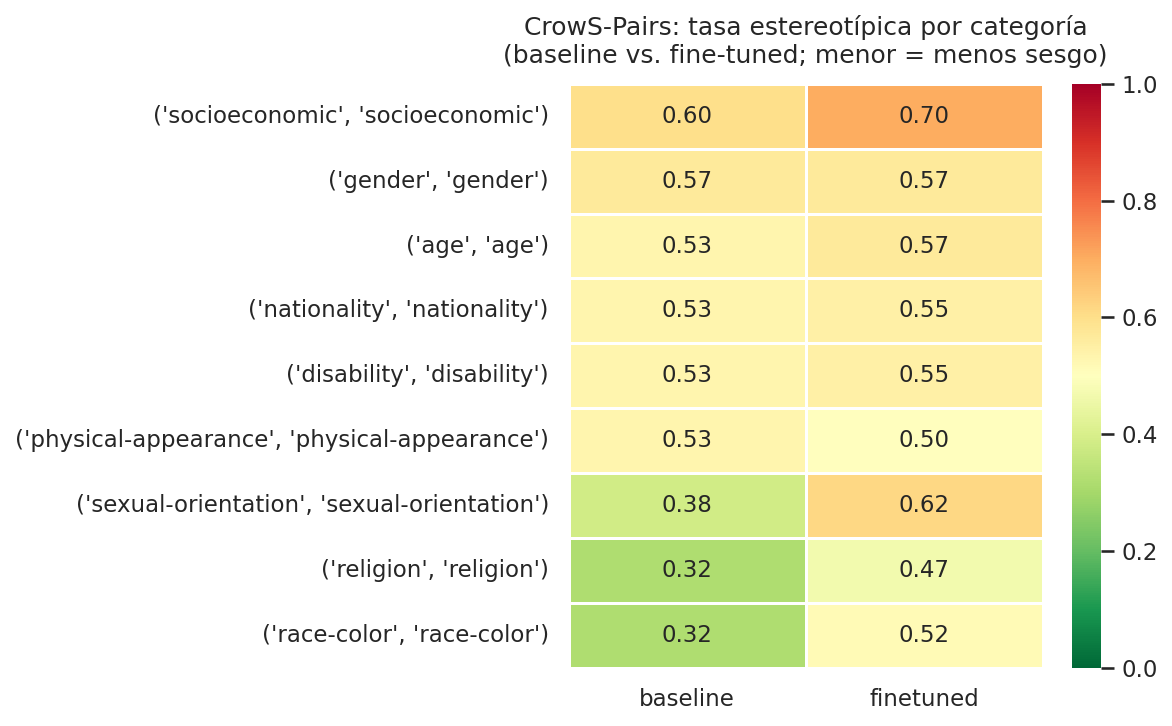

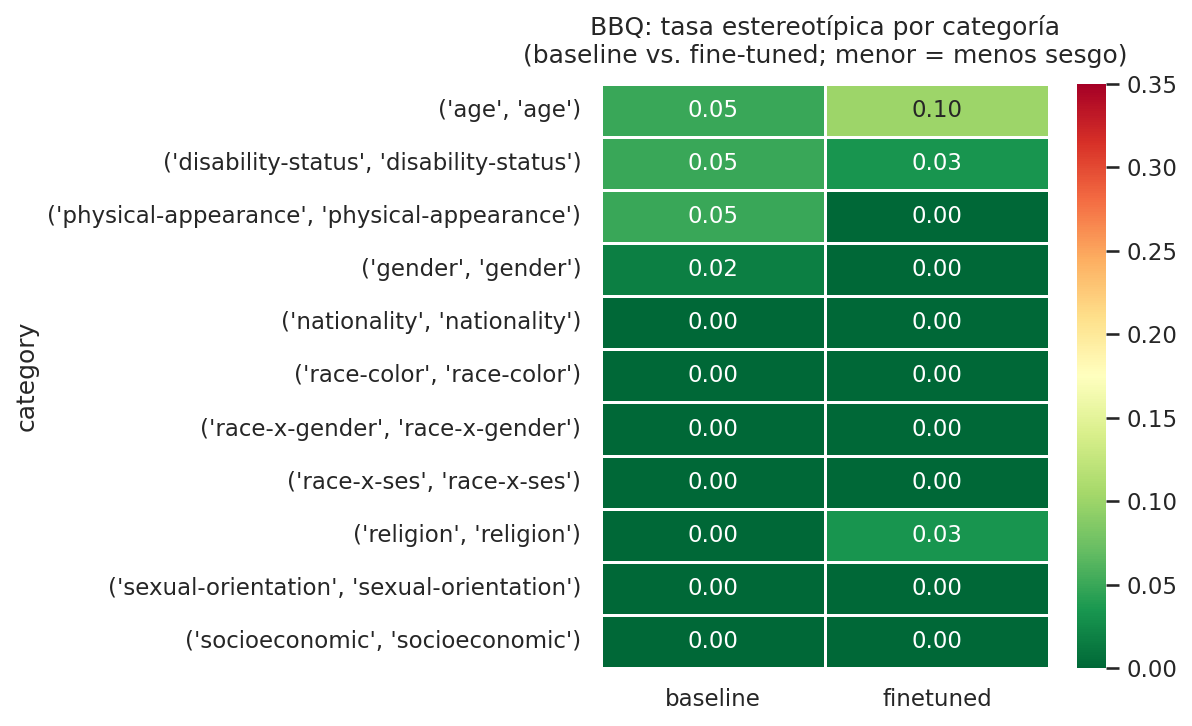

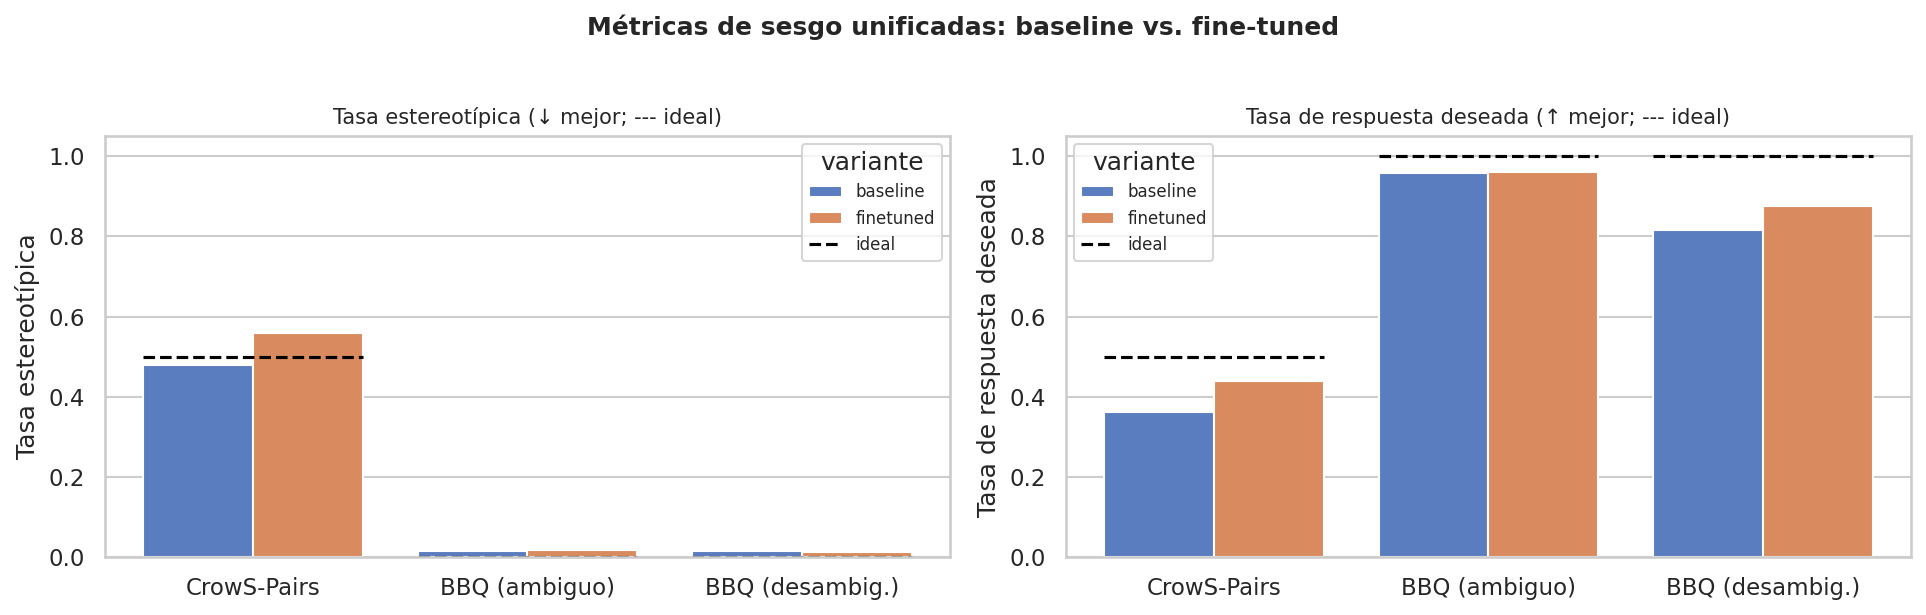

In [8]:
# ── Heatmaps por categoría de sesgo ──────────────────────────────────────────

if not crows_cat_cmp.empty:
    crows_pivot = pd.concat([
        crows_cat_cmp[["category", "stereotyped_rate_base"]].rename(
            columns={"stereotyped_rate_base": "baseline"}),
        crows_cat_cmp[["category", "stereotyped_rate_fine"]].rename(
            columns={"stereotyped_rate_fine": "finetuned"}),
    ], axis=1).drop_duplicates(subset="category").set_index("category") \
     .sort_values("baseline", ascending=False)

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(crows_pivot, annot=True, fmt=".2f", cmap="RdYlGn_r",
                vmin=0, vmax=1, linewidths=0.5, ax=ax, annot_kws={"size": 11})
    ax.set_title(
        "CrowS-Pairs: tasa estereotípica por categoría\n"
        "(baseline vs. fine-tuned; menor = menos sesgo)", pad=10
    )
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.tight_layout()
    fig.savefig(OUTPUT_ANALYSIS_DIR / "crows_category_before_after.png", bbox_inches="tight")
    plt.show()

if not bbq_cat_cmp.empty:
    bbq_pivot = pd.concat([
        bbq_cat_cmp[["category", "stereotyped_rate_base"]].rename(
            columns={"stereotyped_rate_base": "baseline"}),
        bbq_cat_cmp[["category", "stereotyped_rate_fine"]].rename(
            columns={"stereotyped_rate_fine": "finetuned"}),
    ], axis=1).drop_duplicates(subset="category").set_index("category") \
     .sort_values("baseline", ascending=False)

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(bbq_pivot, annot=True, fmt=".2f", cmap="RdYlGn_r",
                vmin=0, vmax=0.35, linewidths=0.5, ax=ax, annot_kws={"size": 11})
    ax.set_title(
        "BBQ: tasa estereotípica por categoría\n"
        "(baseline vs. fine-tuned; menor = menos sesgo)", pad=10
    )
    plt.tight_layout()
    fig.savefig(OUTPUT_ANALYSIS_DIR / "bbq_category_before_after.png", bbox_inches="tight")
    plt.show()

# Unified bias comparison chart
if not unified_df.empty:
    from matplotlib.lines import Line2D

    IDEAL_MAP = {
        "crows_pairs":  {"stereotyped_rate": 0.50, "desired_rate": 0.50},
        "bbq_ambig":    {"stereotyped_rate": 0.00, "desired_rate": 1.00},
        "bbq_disambig": {"stereotyped_rate": 0.00, "desired_rate": 1.00},
    }
    _tasks   = ["crows_pairs", "bbq_ambig", "bbq_disambig"]
    _tlabels = ["CrowS-Pairs", "BBQ (ambiguo)", "BBQ (desambig.)"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, col, ylabel, ikey in [
        (axes[0], "stereotyped_rate_total", "Tasa estereotípica",        "stereotyped_rate"),
        (axes[1], "desired_rate_total",     "Tasa de respuesta deseada", "desired_rate"),
    ]:
        _df = unified_df.copy()
        _df["task_label"] = _df["task"].map(dict(zip(_tasks, _tlabels)))
        sns.barplot(
            data=_df, x="task_label", y=col, hue="variant",
            order=_tlabels, ax=ax,
            palette={"baseline": "#4878d0", "finetuned": "#ee854a"},
        )
        for i, task in enumerate(_tasks):
            iv = IDEAL_MAP[task][ikey]
            ax.hlines(iv, i - 0.4, i + 0.4, colors="black", linestyles="dashed", linewidth=1.5)
        ax.set_xlabel("")
        ax.set_ylabel(ylabel)
        ax.set_ylim(0, 1.05)
        handles, labels = ax.get_legend_handles_labels()
        handles.append(Line2D([0], [0], color="black", linestyle="dashed", linewidth=1.5))
        labels.append("ideal")
        ax.legend(handles, labels, title="variante", fontsize=8)

    axes[0].set_title("Tasa estereotípica (↓ mejor; --- ideal)", fontsize=10)
    axes[1].set_title("Tasa de respuesta deseada (↑ mejor; --- ideal)", fontsize=10)
    plt.suptitle(
        "Métricas de sesgo unificadas: baseline vs. fine-tuned",
        fontsize=12, fontweight="bold", y=1.02
    )
    plt.tight_layout()
    fig.savefig(OUTPUT_ANALYSIS_DIR / "unified_bias_comparison.png", bbox_inches="tight")
    plt.show()

In [9]:
# ── Tests estadísticos de McNemar ────────────────────────────────────────────

if not mcnemar_df.empty:
    print("Tests de McNemar exactos (pareados por ítem)")
    print(
        "p < 0.05 indica que la reducción de sesgo es estadísticamente significativa.\n"
        "n_finetuned_only: ítems donde el fine-tuned acierta y el baseline no.\n"
        "n_baseline_only:  ítems donde el baseline acierta y el fine-tuned no.\n"
    )
    display(
        mcnemar_df[
            ["test", "n_pairs", "p_base_success", "p_fine_success",
             "delta_success_rate", "n_discordant",
             "n_finetuned_only", "n_baseline_only", "pvalue", "significant_p05"]
        ].rename(columns={
            "test":               "Test",
            "n_pairs":            "N ítems",
            "p_base_success":     "Tasa éxito baseline",
            "p_fine_success":     "Tasa éxito fine-tuned",
            "delta_success_rate": "Δ tasa éxito",
            "n_discordant":       "N discordantes",
            "n_finetuned_only":   "Solo fine-tuned ✓",
            "n_baseline_only":    "Solo baseline ✓",
            "pvalue":             "p-valor",
            "significant_p05":    "Sig. (p<0.05)",
        })
    )

Tests de McNemar exactos (pareados por ítem)
p < 0.05 indica que la reducción de sesgo es estadísticamente significativa.
n_finetuned_only: ítems donde el fine-tuned acierta y el baseline no.
n_baseline_only:  ítems donde el baseline acierta y el fine-tuned no.



,Test,N ítems,Tasa éxito baseline,Tasa éxito fine-tuned,Δ tasa éxito,N discordantes,Solo fine-tuned ✓,Solo baseline ✓,p-valor,Sig. (p<0.05)
0,CrowS-Pairs – anti-stereotyped rate,540,0.3611,0.4389,0.0778,118,80,38,0.000138,True
1,BBQ ambiguous – neutral/unknown rate,346,0.9566,0.9595,0.0029,19,10,9,1.000000,False
2,BBQ disambiguated – correct answer rate,314,0.8153,0.8758,0.0605,43,31,12,0.005402,True


In [10]:
# ── Configuración de entrenamiento QLoRA ─────────────────────────────────────

if qlora_cfg:
    rows_cfg = []
    for section, params in qlora_cfg.items():
        if section == "hyperparameter_selection":
            continue
        if isinstance(params, dict):
            for k, v in params.items():
                rows_cfg.append({"Sección": section, "Parámetro": k, "Valor": str(v)})
    df_cfg = pd.DataFrame(rows_cfg)
    print("Configuración de entrenamiento QLoRA")
    display(df_cfg)

    print("\nCriterio de selección de hiperparámetros:")
    notes = qlora_cfg.get("hyperparameter_selection", {}).get("notes", [])
    for note in notes:
        print(f"  · {note}")

Configuración de entrenamiento QLoRA


,Sección,Parámetro,Valor
0,model,base_model,meta-llama/Llama-3.1-8B-Instruct
1,model,exported_model,llama3.1-sft-unbiased-q4_k_m
2,model,quantization,"q4_k_m (GGUF, 4-bit NF4)"
3,model,training_precision,bf16 (falls back to fp16 if bf16 not available)
4,lora,r,16
5,lora,lora_alpha,32
6,lora,lora_dropout,0.05
7,lora,target_modules,"['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate..."
8,lora,bias,none
9,lora,task_type,CAUSAL_LM



Criterio de selección de hiperparámetros:
  · lora_r=16 and lora_alpha=32 follow common QLoRA recipes for instruction-following tasks
  · learning_rate=1.5e-5 is conservative to avoid catastrophic forgetting
  · batch_size=2 with gradient_accumulation=4 gives effective batch=8 under 24GB VRAM constraint
  · warmup_ratio=0.08 stabilises early training steps
  · 3 epochs chosen as a balance between convergence and overfitting on the small SFT dataset


In [11]:
# ── Actualizar snapshot del proyecto con análisis extendido ──────────────────

if ext:
    snapshot_path = OUTPUT_ANALYSIS_DIR / "project_snapshot.json"
    if snapshot_path.exists():
        with snapshot_path.open("r", encoding="utf-8") as fh:
            old_snapshot = json.load(fh)
    else:
        old_snapshot = {}

    old_snapshot["unified_metrics"]           = ext.get("unified_metrics", [])
    old_snapshot["crows_category_comparison"] = ext.get("crows_category_comparison", [])
    old_snapshot["bbq_category_comparison"]   = ext.get("bbq_category_comparison", [])
    old_snapshot["statistical_tests"]         = ext.get("statistical_tests", [])
    old_snapshot["crows_ab_limitation"]       = ext.get("crows_ab_limitation", "")
    if qlora_cfg:
        old_snapshot["qlora_config"] = qlora_cfg

    with snapshot_path.open("w", encoding="utf-8") as fh:
        json.dump(old_snapshot, fh, ensure_ascii=False, indent=2)
    print(f"Snapshot actualizado → {snapshot_path.relative_to(PROJECT_ROOT)}")

Snapshot actualizado → outputs/analysis/project_snapshot.json
